---
# EMITTANCE EXCHANGE, periodic case
---
https://journals.aps.org/prab/abstract/10.1103/PhysRevSTAB.10.064003


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


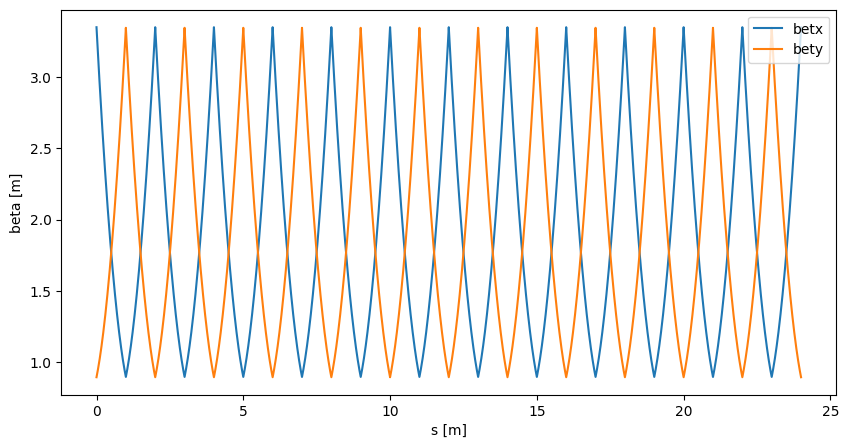

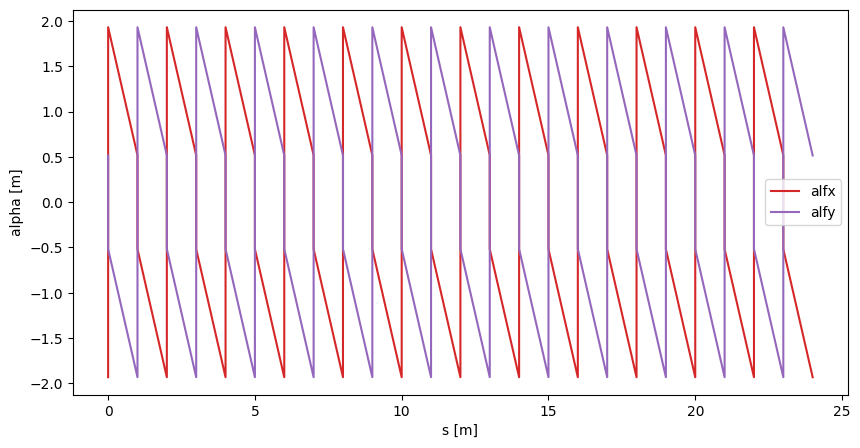

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

import xtrack as xt
import xobjects as xo


# CELL parameters
#-----------------------
L       = 1                 #-- drift length
k       = 2/np.sqrt(3)      #-- focusing strength
dk      = 0.001*k           #-- to split x-y tunes
supP    = 12                 #-- superperiods
divs    = 100               #-- drift divisions (for visualization)
#-----------------------


# ELEMENTS
#=========================================================================================
elements = {}
for n in range(supP):
    cell = {
            f'entry.{n}'        : xt.Marker(),
            f'QF.{n}'           : xt.Multipole(knl=[0, k],ksl=[0,0],length=0),
            **{f'O1.{n}.{i}'    : xt.Drift(length=L/divs) for i in range(divs)},
            f'QD.{n}'           : xt.Multipole(knl=[0,-k],ksl=[0,0],length=0),
            **{f'O2.{n}.{i}'    : xt.Drift(length=L/divs) for i in range(divs)},
        }
    elements.update(cell)
#=========================================================================================

# BEAM & XSUITE LINE
#=========================================================================================
nrj             = 7000e9
particle_ref    = xt.Particles(p0c=nrj, q0=1, mass0=xt.PROTON_MASS_EV)
context         = xo.ContextCpu(omp_num_threads='auto')
nemitt_x        = 2.5e-6
nemitt_y        = 2.5e-6
gemitt_x        = 1 if nemitt_x is None else ( nemitt_x / particle_ref.beta0[0] / particle_ref.gamma0[0])
gemitt_y        = 1 if nemitt_y is None else ( nemitt_y / particle_ref.beta0[0] / particle_ref.gamma0[0])
#-----------------------------------------------------------------------------------------
line = xt.Line(elements=elements)
line.particle_ref = particle_ref
line.build_tracker(_context=context)
# KNOBS
line.vars['k0'] = k
line.vars['dQ'] = dk
line.vars['dC'] = 0
for n in range(supP):
    # Normal Quadrupoles to set tunes
    line.element_refs[f'QF.{n}'].knl[1] =  line.vars['k0'] 
    line.element_refs[f'QD.{n}'].knl[1] = -(line.vars['k0']+line.vars['dQ'])
    # Skew Quadrupoles to set coupling
    line.element_refs[f'QF.{n}'].ksl[1] =  line.vars['dC'] 
    # line.element_refs[f'QD.{n}'].ksl[1] =  line.vars['dC'] 
#=========================================================================================
line.freeze_longitudinal(True)
twiss       = line.twiss4d()
#=========================================================================================


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.betx, label='betx')
plt.plot(twiss.s, twiss.bety, label='bety')
plt.xlabel('s [m]')
plt.ylabel('beta [m]')
plt.legend()


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.alfx, label='alfx',color='C3')
plt.plot(twiss.s, twiss.alfy, label='alfy',color='C4')
plt.xlabel('s [m]')
plt.ylabel('alpha [m]')
plt.legend()

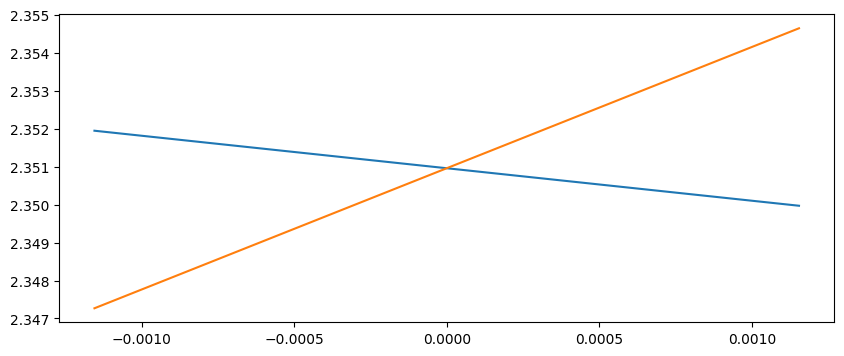

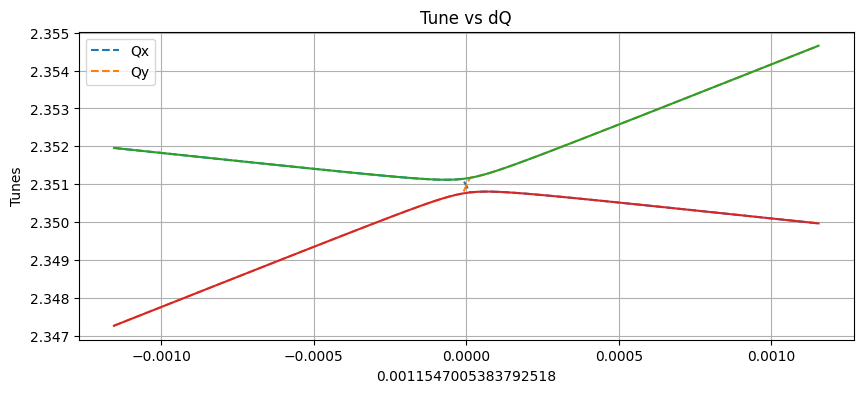

In [3]:

plt.figure(figsize=(10,4))

line.vars['dC'] = 0
qx0 = []
qy0 = []
dQ_vec = np.linspace(-dk,dk,100)
for dQ in dQ_vec:
    line.vars['dQ'] = dQ
    twiss       = line.twiss4d()
    qx0.append(twiss.qx)
    qy0.append(twiss.qy)
plt.plot(dQ_vec,qx0)
plt.plot(dQ_vec,qy0)



plt.figure(figsize=(10,4))
line.vars['dC'] = 0.1*dk
qx = []
qy = []
C  = []
dQ_vec = np.linspace(-dk,dk,100)
for dQ in dQ_vec:
    line.vars['dQ'] = dQ
    twiss       = line.twiss4d()
    qx.append(twiss.qx)
    qy.append(twiss.qy)
    C.append(twiss.c_minus)
plt.plot(dQ_vec,qx,'--')
plt.plot(dQ_vec,qy,'--')

DD = np.array(qx0)-np.array(qy0)
Q1 = (np.array(qx0)+np.array(qy0))/2 +np.sqrt((DD)**2 + np.array(C)**2)/2
Q2 = (np.array(qx0)+np.array(qy0))/2 -np.sqrt((DD)**2 + np.array(C)**2)/2

plt.plot(dQ_vec,Q1,'-')
plt.plot(dQ_vec,Q2,'-')
plt.xlabel(dQ)
plt.ylabel('Tunes')
plt.title('Tune vs dQ')
plt.legend(['Qx','Qy'])
plt.grid()


np.float64(0.0)